In [1]:
#Import libraries and specify paths

import pandas as pd
import numpy  as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics  import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("Librarties imported")

train_csv=r"C:\Users\NARASIMHA N\OneDrive\Desktop\Kitsune Feature Extraction\Dataset Preprocessing\IoT Network Intrusion Dataset\Training and Testing CSVs\IoT_NID_train.csv"
test_csv=r"C:\Users\NARASIMHA N\OneDrive\Desktop\Kitsune Feature Extraction\Dataset Preprocessing\IoT Network Intrusion Dataset\Training and Testing CSVs\IoT_NID_test.csv"

print("Paths are set")

Librarties imported
Paths are set


In [2]:
#load train and test data

train_df=pd.read_csv(train_csv)
test_df=pd.read_csv(test_csv)

print(f"Train CSV: {train_df.shape}")
print(f"Test CSV: {test_df.shape}")

print(f"\nTrain label Distribution: {train_df['label'].value_counts().to_dict()}")
print(f"\nTest label Distribution: {test_df['label'].value_counts().to_dict()}")

Train CSV: (32000, 104)
Test CSV: (8000, 104)

Train label Distribution: {0: 16000, 1: 16000}

Test label Distribution: {1: 4000, 0: 4000}


In [3]:
#Separate features and label

feature_columns=[feature for feature in train_df.columns if feature!='label']

X_train=train_df[feature_columns]
y_train=train_df['label']

X_test=test_df[feature_columns]
y_test=test_df['label']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution: {y_train.value_counts().to_dict()}")
print(f"y_test distribution: {y_test.value_counts().to_dict()}")

X_train shape: (32000, 103)
X_test shape: (8000, 103)
y_train distribution: {0: 16000, 1: 16000}
y_test distribution: {1: 4000, 0: 4000}


In [4]:
# Definition of all models

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

print("Models Defined:")
for i in models:
    print(i)

Models Defined:
Decision Tree
Random Forest
KNN
SVM
Logistic Regression
XGBoost


In [7]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cross_validation_results=[]

print("Running 5-fold Cross-validation on training set....")

for model_name, model in models.items():
    print(f"Cross Validating {model_name}....")

    cross_validadtion_scores=cross_val_score(model, X_train, y_train, cv=skf, scoring="f1")

    cross_validation_results.append({
        "Model": model_name,
        "CV Mean F1": round(cross_validadtion_scores.mean(),4),
        "CV Std F1": round(cross_validadtion_scores.std(),4),
        "CV Min F1": round(cross_validadtion_scores.min(),4),
        "CV Max F1": round(cross_validadtion_scores.max(),4)
    })

    print(f"Fold Scores: {[round(s,4) for s in cross_validadtion_scores]}")
    print(f"Mean F1: {cross_validadtion_scores.mean()}")
    print(f"\nStd F1: {cross_validadtion_scores.std()}")

cross_validation_results_df=pd.DataFrame(cross_validation_results)
cross_validation_results_df=cross_validation_results_df.sort_values('CV Mean F1', ascending =False).reset_index(drop=True)
print("Cross Validation Results:\n")
print(cross_validation_results_df.to_string(index=False))

Running 5-fold Cross-validation on training set....
Cross Validating Decision Tree....
Fold Scores: [np.float64(0.9997), np.float64(0.9995), np.float64(0.9997), np.float64(0.9998), np.float64(0.9995)]
Mean F1: 0.9996561962776156

Std F1: 0.00011694506926724614
Cross Validating Random Forest....
Fold Scores: [np.float64(0.9998), np.float64(1.0), np.float64(1.0), np.float64(0.9998), np.float64(0.9997)]
Mean F1: 0.9998749706954934

Std F1: 0.00011696073376784334
Cross Validating KNN....
Fold Scores: [np.float64(0.998), np.float64(0.9991), np.float64(0.9994), np.float64(0.9992), np.float64(0.9975)]
Mean F1: 0.9986270568051643

Std F1: 0.0007466506829849201
Cross Validating SVM....
Fold Scores: [np.float64(0.9978), np.float64(0.9986), np.float64(0.9992), np.float64(0.9991), np.float64(0.9983)]
Mean F1: 0.9985954128501877

Std F1: 0.0005123537133218596
Cross Validating Logistic Regression....
Fold Scores: [np.float64(0.997), np.float64(0.9989), np.float64(0.9989), np.float64(0.9994), np.floa

In [10]:
#Train and evaluate all models
import time
results=[]

for model_name, model in models.items():
    print(f"Training {model_name}....")

    #train the model on train data
    start_time=time.time()
    model.fit(X_train, y_train)
    end_time=time.time()
    training_time=end_time-start_time

    #predict on test data
    start_time=time.time()
    y_pred=model.predict(X_test)
    end_time=time.time()
    testing_time=end_time-start_time
    
    #metrics calculation
    accuracy=accuracy_score(y_test, y_pred)
    precision=precision_score(y_test, y_pred)
    recall=recall_score(y_test, y_pred)
    f1=f1_score(y_test, y_pred)

    #Storing results
    results.append({
         'Model': model_name,
         'Accuracy': round(accuracy,4),
         'Precision': round(precision,4),
         'Recall': round(recall,4),
         'F1-Score': round(f1,4),
         'Training Time (S)': training_time,
         'Testing Time (S)': testing_time
     })
    print(f"Model Name: {model_name}")
    print(f"Accuracy {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1-Score: {f1}")
    print(f"Training Time: {training_time} seconds")
    print(f"Testing Time: {testing_time} seconds")
     

print("\n All models are trained and evaluated")       
    

Training Decision Tree....
Model Name: Decision Tree
Accuracy 0.9995
Precision: 1.0
Recall: 0.999
F1-Score: 0.9994997498749375
Training Time: 1.4967083930969238 seconds
Testing Time: 0.012623786926269531 seconds
Training Random Forest....
Model Name: Random Forest
Accuracy 0.999875
Precision: 1.0
Recall: 0.99975
F1-Score: 0.9998749843730467
Training Time: 25.347026348114014 seconds
Testing Time: 0.0972440242767334 seconds
Training KNN....
Model Name: KNN
Accuracy 0.999125
Precision: 0.9982530571499876
Recall: 1.0
F1-Score: 0.9991257649556637
Training Time: 0.06366419792175293 seconds
Testing Time: 2.914400100708008 seconds
Training SVM....
Model Name: SVM
Accuracy 0.999125
Precision: 0.9982530571499876
Recall: 1.0
F1-Score: 0.9991257649556637
Training Time: 5.859920024871826 seconds
Testing Time: 1.2504851818084717 seconds
Training Logistic Regression....
Model Name: Logistic Regression
Accuracy 0.99925
Precision: 0.9985022466300549
Recall: 1.0
F1-Score: 0.9992505620784412
Training Tim

In [11]:
results_df=pd.DataFrame(results)

results_df=results_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("IoT-Network Intrusion Dataset Model Comparision:")
print(results_df.to_string(index=False))

IoT-Network Intrusion Dataset Model Comparision:
              Model  Accuracy  Precision  Recall  F1-Score  Training Time (S)  Testing Time (S)
      Random Forest    0.9999     1.0000  0.9998    0.9999          25.347026          0.097244
            XGBoost    0.9999     1.0000  0.9998    0.9999           3.836008          0.054300
      Decision Tree    0.9995     1.0000  0.9990    0.9995           1.496708          0.012624
Logistic Regression    0.9992     0.9985  1.0000    0.9993           1.750539          0.015652
                SVM    0.9991     0.9983  1.0000    0.9991           5.859920          1.250485
                KNN    0.9991     0.9983  1.0000    0.9991           0.063664          2.914400


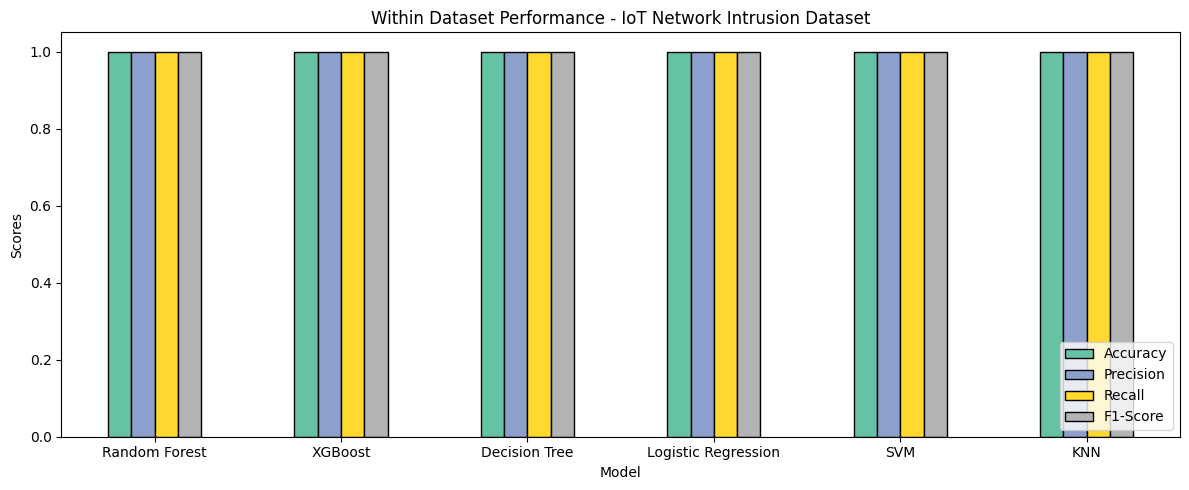

In [8]:
import matplotlib.pyplot as plt

plot_df = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].copy()
plot_df = plot_df.apply(pd.to_numeric, errors="coerce")

plot_df.plot(
    kind="bar",
    figsize=(12, 5),
    ylim=(0, 1.05),
    colormap="Set2",
    edgecolor="black"
)

plt.title("Within Dataset Performance - IoT Network Intrusion Dataset")
plt.xlabel("Model")
plt.ylabel("Scores")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [15]:
# Feature Importance

rf = models['Random Forest']
xgb = models['XGBoost']

rf_importance= pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

xgb_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Top 20 features - Random Forest:")
print(rf_importance.head(20).to_string(index=False))

print("\nTop 20 features - XGBoost:")
print(xgb_importance.head(20).to_string(index=False))

common_top20_features = set(xgb_importance.head(20)['Feature']) & set(rf_importance.head(20)['Feature'])
for feature in common_top20_features:
    print(feature)

Top 20 features - Random Forest:
                Feature  Importance
   HpHp_0.01_radius_0_1    0.130749
     HH_0.01_radius_0_1    0.129234
HpHp_0.01_magnitude_0_1    0.094035
  HH_0.01_magnitude_0_1    0.077999
  HH_0.1_covariance_0_1    0.065298
   HH_0.1_magnitude_0_1    0.046409
 HH_0.01_covariance_0_1    0.044161
 HpHp_0.1_magnitude_0_1    0.038602
         HH_0.01_mean_0    0.034296
      HH_0.1_radius_0_1    0.026041
       MI_dir_0.01_mean    0.025800
    HpHp_0.1_radius_0_1    0.022225
       HpHp_0.01_mean_0    0.017974
        HH_0.01_pcc_0_1    0.017822
        HH_jit_0.1_mean    0.015422
          HH_0.1_mean_0    0.014642
      HH_jit_0.1_weight    0.013988
        HH_jit_0.01_std    0.012539
         HH_0.1_pcc_0_1    0.010886
        HH_jit_1_weight    0.010346

Top 20 features - XGBoost:
                Feature  Importance
  HH_0.01_magnitude_0_1    0.463148
HpHp_0.01_magnitude_0_1    0.351712
      HH_jit_0.1_weight    0.069316
        HH_jit_1_weight    0.016740
   

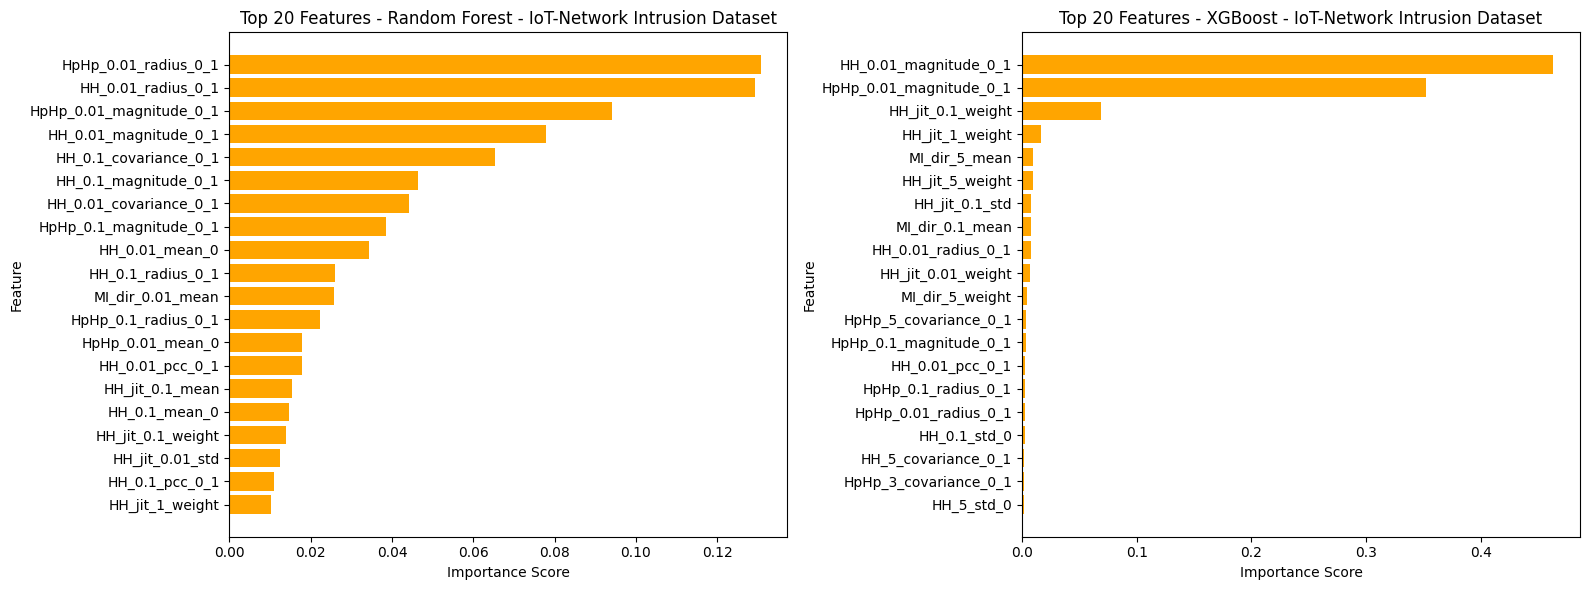

In [14]:
#plot top-20 features
import matplotlib.pyplot as plt


fig, axes=plt.subplots(1,2,figsize=(16,6))

top20_rf=rf_importance.head(20)
axes[0].barh(top20_rf['Feature'][::-1], top20_rf['Importance'][::-1], color='orange')
axes[0].set_title('Top 20 Features - Random Forest - IoT-Network Intrusion Dataset')
axes[0].set_xlabel('Importance Score')
axes[0].set_ylabel('Feature')

top20_xgb=xgb_importance.head(20)
axes[1].barh(top20_xgb['Feature'][::-1], top20_xgb['Importance'][::-1], color='orange')
axes[1].set_title('Top 20 Features - XGBoost - IoT-Network Intrusion Dataset')
axes[1].set_xlabel('Importance Score')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.show()